# Ground Condition Predictor v2 — Enhanced Model

**What's new vs v1:**
- Session-level pressure & impact normalisation (removes shoe/body-weight offset)
- Ratio features instead of raw magnitudes (body-weight invariant)
- Temporal heel-curve shape features: time-to-peak, impulse, rise/fall slope asymmetry, skewness, kurtosis
- Gyroscope features at heel strike and across stance (ankle stability)
- Step-to-step rolling consistency features (surface texture signal)
- Sequence smoothing post-processing (majority vote over 5-step window)
- **Composite score** combining Accuracy + Macro F1 + Brick F1

**Surface mapping:**

| Raw label | Class |
|---|---|
| brick, concrete, asphalt | `paved` |
| grass | `grass` |
| compact ground, dirt, exposed aggregate | `loose` |

## 0. Imports & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter
from scipy.stats import skew, kurtosis as scipy_kurtosis
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
import warnings; warnings.filterwarnings('ignore')
import os, glob, shutil

# ── Sensor groups ─────────────────────────────────────────────────────
HEEL_SENSORS     = ['pressure_08', 'pressure_11']
FOREFOOT_SENSORS = ['pressure_02', 'pressure_04', 'pressure_05',
                    'pressure_06', 'pressure_09']
ALL_SENSORS      = [f'pressure_{i:02d}' for i in range(1, 13)]

# ── Algorithm parameters ──────────────────────────────────────────────
SMOOTH_WIN=11; SMOOTH_POLY=2; PEAK_DIST=50; PEAK_PROM=200; PEAK_HT=500
SAMPLING_HZ=62.5; HILL_WIN=10; MIN_DP=5

# ── Surface normalisation map ─────────────────────────────────────────
SURFACE_MAP = {
    'grass': 'grass',
    'compact ground': 'loose', 'dirt': 'loose', 'exposed aggregate': 'loose',
    'brick': 'paved', 'concrete': 'paved', 'asphalt': 'paved',
}
BASE_COLS = set(
    ['sole_id','timestamp','accel_x','accel_y','accel_z',
     'gyro_x','gyro_y','gyro_z','magn_x','magn_y','magn_z','corrupt']
    + [f'pressure_{i:02d}' for i in range(1,13)]
)
SURFACE_COLORS = {'grass':'#4CAF50','loose':'#8D6E63','paved':'#607D8B','unknown':'#9E9E9E'}

# ── Composite score weights ───────────────────────────────────────────
# Rewards balanced performance across all classes, with extra weight on
# Brick (hardest class to separate from Concrete)
W_ACC=0.30; W_MACRO_F1=0.50; W_FOCUS_F1=0.20
FOCUS_CLASS = 'loose'   # class the composite score up-weights (was 'brick')

# ── Session-invariant texture / frequency features ────────────────────
# Target the brick-vs-concrete boundary (both rigid; magnitude features can't
# separate them). These are ratios / rates / spectral shape, so they carry no
# body-weight or shoe scale and should transfer across sessions. Toggle to
# ablate, then RE-RUN SECTION 2 (features are computed at compile time).
USE_TEXTURE_FEATURES = True

# ── Repository layout ─────────────────────────────────────────────────
# This notebook lives in the XGBoost/ folder; the repo root is one level up.
# Rename any of these to match your actual folder names.
REPO_ROOT   = '..'
USERS_DIR   = os.path.join(REPO_ROOT, 'Individual Users')   # one subfolder per user (Amy, Catherine, Kristian, ...)
CHARTS_DIR  = os.path.join(REPO_ROOT, 'Charts_Graphs')      # dashboard / distribution / smoothing PNGs
PRED_DIR    = os.path.join(REPO_ROOT, 'Prediction Results') # exported prediction CSVs
SVG_DIR     = os.path.join(REPO_ROOT, 'SVG Outputs')        # (defined for completeness; this notebook writes no SVGs)
RAW_NEW_DIR = os.path.join(REPO_ROOT, 'Raw_New Data')       # must hold exactly ONE REC_*.csv to predict on

# Compiled per-material training data frames (written in Section 2, read for training).
MATERIAL_CSVS = {
    'grass': os.path.join(REPO_ROOT, 'grass_dry.csv'),
    'loose': os.path.join(REPO_ROOT, 'loose_dry.csv'),
    'paved': os.path.join(REPO_ROOT, 'paved_dry.csv'),
}
REC_GLOB = 'REC_*.csv'   # recording file naming convention

for _d in (CHARTS_DIR, PRED_DIR, SVG_DIR):
    os.makedirs(_d, exist_ok=True)

print('Ready.')

Ready.


## 1. Core Functions

In [2]:
def get_surface_cols(df):
    return [c for c in df.columns if c not in BASE_COLS and c in SURFACE_MAP]


def label_surface_segments(df):
    """
    Parse 'x' markers in extra columns to label each row with a surface.
    Each marker indicates the START of that surface type.
    """
    surf_cols = get_surface_cols(df)
    if not surf_cols: return None
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    events = []
    for col in surf_cols:
        mask = df[col].notna() & (df[col].astype(str).str.strip() == 'x')
        for idx in df.index[mask]:
            events.append((int(idx), SURFACE_MAP[col]))
    if not events: return None
    events.sort()
    df['surface'] = None
    for i, (start_idx, surf) in enumerate(events):
        end_idx = events[i+1][0] if i+1 < len(events) else len(df)
        df.loc[start_idx:end_idx-1, 'surface'] = surf
    return df[df['surface'].notna()].copy()


def preprocess(df):
    df = df.copy().sort_values('timestamp').reset_index(drop=True)
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['time_sec']  = (df['timestamp'] - df['timestamp'].iloc[0]) / 1000.0
    return df


def find_step_windows(df):
    y_comb = sum(
        pd.to_numeric(df[s], errors='coerce').fillna(0).to_numpy(dtype=float)
        for s in HEEL_SENSORS if s in df.columns
    )
    n=len(y_comb); sw=min(SMOOTH_WIN, n-(0 if n%2==1 else 1))
    if sw%2==0: sw-=1
    if sw<=SMOOTH_POLY: sw=SMOOTH_POLY+3+(1 if (SMOOTH_POLY+3)%2==0 else 0)
    y_sm = savgol_filter(y_comb, window_length=sw, polyorder=min(SMOOTH_POLY, sw-1))
    peaks, _ = find_peaks(y_sm, distance=PEAK_DIST, prominence=PEAK_PROM, height=PEAK_HT)
    return peaks


def compute_session_stats(df):
    """
    Compute session-level normalisation anchors from the full raw recording.
    Used to remove shoe/body-weight offsets between sessions.
    """
    total_p = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    accel_y = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    valid   = total_p[total_p > 0]
    return {
        'total_p_mean': float(np.mean(valid)) if len(valid) else 1.0,
        'total_p_std':  float(np.std(valid))  if len(valid) else 1.0,
        'impact_mean':  float(np.mean(np.abs(accel_y))),
        'impact_std':   float(np.std(np.abs(accel_y))) + 1e-9,
    }


def _spec_features(sig, fs=SAMPLING_HZ, hf_cut=5.0):
    """Spectral centroid (Hz), high-freq power fraction, and normalised
    spectral entropy of a within-step signal. Linear-detrended so the stance
    loading curve doesn't dominate; power-normalised so amplitude drops out."""
    x = np.asarray(sig, float); n = len(x)
    if n < 8 or np.allclose(x, x[0]): return 0.0, 0.0, 0.0
    t = np.arange(n); x = x - np.polyval(np.polyfit(t, x, 1), t)
    P = np.abs(np.fft.rfft(x))**2; f = np.fft.rfftfreq(n, 1.0/fs); tot = P.sum()
    if tot <= 0: return 0.0, 0.0, 0.0
    centroid = float((f*P).sum()/tot)
    hf_frac  = float(P[f >= hf_cut].sum()/tot)
    p = P/tot; p = p[p > 0]
    entropy  = float(-(p*np.log(p)).sum()/np.log(len(P))) if len(P) > 1 else 0.0
    return centroid, hf_frac, entropy


def _roughness(sig):
    """Zero-crossing rate of the detrended signal and jerk-to-signal RMS ratio.
    Both amplitude-invariant roughness proxies."""
    x = np.asarray(sig, float); n = len(x)
    if n < 4: return 0.0, 0.0
    xd = x - x.mean()
    zcr = np.sum(np.diff(np.sign(xd)) != 0) / max(n-1, 1)
    jerk = np.diff(x)
    jr  = float(np.sqrt(np.mean(jerk**2)) / (np.sqrt(np.mean(xd**2)) + 1e-9))
    return float(zcr), jr


def _ripple_frac(sig, win=SMOOTH_WIN, poly=SMOOTH_POLY):
    """Fraction of signal energy left after removing the smooth loading trend —
    i.e. relative high-frequency micro-vibration (mortar-joint chatter)."""
    x = np.asarray(sig, float); n = len(x)
    if n < 8: return 0.0
    w = min(win, n-(0 if n % 2 == 1 else 1))
    if w % 2 == 0: w -= 1
    if w <= poly: return 0.0
    resid = x - savgol_filter(x, w, poly)
    return float(np.sum(resid**2) / (np.sum(x**2) + 1e-9))


print('Helper functions defined.')

Helper functions defined.


In [3]:
def extract_step_features(df, surface_label='unknown', foot_label='unknown', session_stats=None):
    """
    Extract enhanced per-step feature set.

    Feature groups:
    - Timing:          stance_duration, time_to_peak_frac
    - Impact:          impact_mag (raw + session-normalised), accel_mag_strike
    - Loading rate:    loading_rate (raw + session-normalised)
    - Pressure ratios: heel/fore pmax and mean as fraction of total (body-weight invariant)
    - Heel curve shape: impulse, rise/fall slope, asymmetry, skewness, kurtosis
    - Midstance:       heel-forefoot balance at midstance
    - Gyroscope:       magnitude & axes at heel strike, std across stance
    - Consistency:     rolling 3-step std of impact, loading rate, stance duration
    - Per-sensor:      mean of each of 12 sensors normalised by total pressure
    """
    df = df.copy().reset_index(drop=True)
    t         = df['time_sec'].values
    heel_sig  = df[HEEL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    fore_sig  = df[FOREFOOT_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values
    heel_norm = heel_sig / len(HEEL_SENSORS)
    fore_norm = fore_sig / len(FOREFOOT_SENSORS)
    accel_y   = pd.to_numeric(df['accel_y'], errors='coerce').fillna(0).values
    accel_x   = pd.to_numeric(df['accel_x'], errors='coerce').fillna(0).values
    accel_z   = pd.to_numeric(df['accel_z'], errors='coerce').fillna(0).values
    gyro_x    = pd.to_numeric(df['gyro_x'],  errors='coerce').fillna(0).values
    gyro_y    = pd.to_numeric(df['gyro_y'],  errors='coerce').fillna(0).values
    gyro_z    = pd.to_numeric(df['gyro_z'],  errors='coerce').fillna(0).values
    total_p   = df[ALL_SENSORS].apply(pd.to_numeric, errors='coerce').sum(1).fillna(0).values

    if session_stats is None:
        session_stats = compute_session_stats(df)

    peaks = find_step_windows(df)
    if len(peaks) < 2: return pd.DataFrame()

    rows = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        wh=heel_sig[p1:p2]; wf=fore_sig[p1:p2]
        whn=heel_norm[p1:p2]; wfn=fore_norm[p1:p2]
        way=accel_y[p1:p2]; wax=accel_x[p1:p2]; waz=accel_z[p1:p2]
        wgx=gyro_x[p1:p2]; wgy=gyro_y[p1:p2]; wgz=gyro_z[p1:p2]
        wtp=total_p[p1:p2]; wt=t[p1:p2]
        if len(wh) < MIN_DP: continue

        n_win  = len(wh)
        c_loc  = int(np.argmin(wh))
        diff   = np.abs(whn[c_loc:] - wfn[c_loc:])
        m_loc  = c_loc + int(np.argmin(diff))
        hw     = min(int(0.15 * SAMPLING_HZ), n_win - 1)
        impact = float(np.max(np.abs(way[max(0,c_loc-hw):c_loc+hw+1])))

        # Loading rate
        lr_vals = []
        for s in HEEL_SENSORS:
            if s not in df.columns: continue
            sy=pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
            hlo=int(np.argmin(sy)); seg=sy[hlo:min(hlo+HILL_WIN,len(sy))]
            if len(seg)<2: continue
            lp,_=find_peaks(seg,prominence=1)
            hhi=lp[0] if len(lp) else int(np.argmax(seg[1:]))+1
            rise=float(sy[hlo+hhi]-sy[hlo]); dt_lr=hhi/SAMPLING_HZ
            if dt_lr>0 and rise>MIN_DP: lr_vals.append(rise/dt_lr)
        lr = float(np.mean(lr_vals)) if lr_vals else 0.0

        # Surface label from within-step majority
        step_surf = surface_label
        if 'surface' in df.columns:
            step_surfs = df['surface'].iloc[p1:p2].dropna()
            if len(step_surfs): step_surf = step_surfs.mode()[0]

        stance_dur     = float(wt[-1]-wt[0]) if len(wt)>1 else 0.0
        total_p_mean_s = float(np.mean(wtp)) if len(wtp) else 1.0
        norm_denom     = max(total_p_mean_s, 1.0)
        total_pmax     = float(np.max(wtp)) if len(wtp) else 0.0
        heel_pmax_v    = float(np.max(wh))
        fore_pmax_v    = float(np.max(wf))
        heel_mean_v    = float(np.mean(wh))
        fore_mean_v    = float(np.mean(wf))

        # Heel curve temporal shape
        peak_idx_h     = int(np.argmax(wh))
        time_to_peak_f = peak_idx_h / max(n_win-1, 1)
        heel_impulse   = float(np.trapezoid(wh)) / max(n_win, 1)
        rise_slope     = (wh[peak_idx_h] - wh[0]) / max(peak_idx_h, 1)
        tail           = wh[peak_idx_h:]
        fall_slope     = (tail[-1]-tail[0]) / max(len(tail)-1,1) if len(tail)>1 else 0.0
        slope_asym     = rise_slope - abs(fall_slope)
        heel_skew_v    = float(skew(wh)) if len(wh)>2 else 0.0
        heel_kurt_v    = float(scipy_kurtosis(wh)) if len(wh)>3 else 0.0

        # Session-normalised impact and loading rate
        impact_norm = (impact - session_stats['impact_mean']) / session_stats['impact_std']
        lr_norm     = lr / max(session_stats['total_p_mean'], 1.0)

        # Gyroscope at heel strike
        gyro_sl  = slice(max(0,c_loc-hw), min(c_loc+hw+1, n_win))
        gx_s     = float(np.max(np.abs(wgx[gyro_sl]))) if len(wgx[gyro_sl]) else 0.0
        gy_s     = float(np.max(np.abs(wgy[gyro_sl]))) if len(wgy[gyro_sl]) else 0.0
        gz_s     = float(np.max(np.abs(wgz[gyro_sl]))) if len(wgz[gyro_sl]) else 0.0
        gyro_mag = float(np.sqrt(gx_s**2 + gy_s**2 + gz_s**2))

        # Resultant acceleration at strike
        accel_mag_s = float(np.max(
            np.sqrt(wax**2+way**2+waz**2)[max(0,c_loc-hw):c_loc+hw+1]
        )) if n_win > 0 else 0.0

        row = {
            'foot': foot_label, 'step_id': i, 'surface': step_surf,
            'contact_time_sec':   float(wt[0]) if len(wt) else 0.0,
            # Timing
            'stance_duration':    stance_dur,
            'time_to_peak_frac':  time_to_peak_f,
            # Impact
            'impact_mag':         impact,
            'impact_mag_norm':    impact_norm,
            'accel_mag_strike':   accel_mag_s,
            # Loading
            'loading_rate':       lr,
            'loading_rate_norm':  lr_norm,
            # Pressure ratios (body-weight invariant)
            'heel_pmax_ratio':    heel_pmax_v / max(total_pmax, 1.0),
            'fore_pmax_ratio':    fore_pmax_v / max(total_pmax, 1.0),
            'heel_mean_ratio':    heel_mean_v / norm_denom,
            'fore_mean_ratio':    fore_mean_v / norm_denom,
            'heel_fore_ratio':    heel_mean_v / (fore_mean_v + 1e-9),
            'total_pmax':         total_pmax,
            'total_p_mean':       total_p_mean_s,
            'midstance_diff':     float(whn[m_loc]-wfn[m_loc]) if m_loc<len(whn) else 0.0,
            # Heel curve shape
            'heel_impulse':       heel_impulse,
            'heel_impulse_norm':  heel_impulse / norm_denom,
            'rise_slope':         rise_slope,
            'fall_slope':         fall_slope,
            'slope_asym':         slope_asym,
            'heel_skew':          heel_skew_v,
            'heel_kurt':          heel_kurt_v,
            # Gyro
            'gyro_mag_strike':    gyro_mag,
            'gyro_x_strike':      gx_s,
            'gyro_y_strike':      gy_s,
            'gyro_z_strike':      gz_s,
            'gyro_x_std':         float(np.std(wgx)),
            'gyro_y_std':         float(np.std(wgy)),
            'gyro_z_std':         float(np.std(wgz)),
        }
        # Per-sensor normalised means
        for s in ALL_SENSORS:
            if s in df.columns:
                seg_s = pd.to_numeric(df[s],errors='coerce').fillna(0).values[p1:p2]
                row[f'{s}_mean_ratio'] = float(np.mean(seg_s)) / norm_denom
        if USE_TEXTURE_FEATURES:
            amag = np.sqrt(wax**2 + way**2 + waz**2)
            gmag = np.sqrt(wgx**2 + wgy**2 + wgz**2)
            a_cent, a_hf, a_ent = _spec_features(amag)
            _, g_hf, _          = _spec_features(gmag)
            a_zcr, a_jerk       = _roughness(way)
            row.update({
                'accel_spec_centroid': a_cent,
                'accel_hf_frac':       a_hf,
                'accel_spec_entropy':  a_ent,
                'accel_zcr':           a_zcr,
                'accel_jerk_ratio':    a_jerk,
                'gyro_hf_frac':        g_hf,
                'heel_ripple_frac':    _ripple_frac(wh),
            })
        rows.append(row)

    result = pd.DataFrame(rows)
    # Step-to-step rolling consistency (3-step window std)
    if len(result) >= 3:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = result[col].rolling(3, min_periods=1).std().fillna(0)
    else:
        for col in ['impact_mag', 'loading_rate', 'stance_duration']:
            result[f'{col}_roll3_std'] = 0.0
    return result


def rolling_majority(series, window=5):
    """Smooth per-step predictions with a majority vote over a sliding window."""
    smoothed = series.copy()
    for i in range(len(series)):
        w = series.iloc[max(0, i-window//2):min(len(series), i+window//2+1)]
        smoothed.iloc[i] = w.mode()[0]
    return smoothed


def composite_score(acc, macro_f1, focus_f1):
    """
    Single scalar summary of model quality.
    Rewards accuracy (30%), balanced class performance (50%), and
    performance on the focus class FOCUS_CLASS (20%).
    """
    return W_ACC * acc + W_MACRO_F1 * macro_f1 + W_FOCUS_F1 * focus_f1


print('Feature extraction functions defined.')

Feature extraction functions defined.


## 2. Compile & Load Training Data

The per-material data frames (`grass_dry.csv`, `paved_dry.csv`, `(part of paved)_dry.csv`) are
**compiled from every `REC_*.csv` recording found in the `Individual Users` folders**.

Each recording is segmented by its surface markers and feature-extracted using its **own
per-recording normalisation anchor** (`compute_session_stats`) *before* the steps are pooled
by surface. Doing the normalisation per recording — not on the pooled file — is what keeps
the session-level shoe / body-weight correction valid across users and sessions.

In [4]:
# ── 2a. Compile material data frames from every user recording ────────
recordings = []
if not os.path.isdir(USERS_DIR):
    print(f'[WARN] Users folder not found: {USERS_DIR}')
else:
    for user in sorted(os.listdir(USERS_DIR)):
        udir = os.path.join(USERS_DIR, user)
        if not os.path.isdir(udir):
            continue
        for f in sorted(glob.glob(os.path.join(udir, REC_GLOB))):
            recordings.append((user, f))

print(f'Found {len(recordings)} recording(s) across user folders.')

material_frames = {m: [] for m in MATERIAL_CSVS}
for user, path in recordings:
    raw = pd.read_csv(path, low_memory=False)
    ss  = compute_session_stats(raw)                 # per-recording normalisation anchor
    for sole_id, foot in [(1, 'right'), (2, 'left')]:
        sub = raw[raw['sole_id'] == sole_id].copy()
        labelled = label_surface_segments(sub)
        if labelled is None or len(labelled) == 0:
            continue
        labelled = preprocess(labelled)
        feats = extract_step_features(labelled, foot_label=foot, session_stats=ss)
        if not len(feats):
            continue
        feats['source_user']      = user
        feats['source_recording'] = os.path.basename(path)
        for surf, grp in feats.groupby('surface'):
            if surf in material_frames:
                material_frames[surf].append(grp)

print('\nWriting compiled material files:')
for surf, out in MATERIAL_CSVS.items():
    if material_frames[surf]:
        mdf = pd.concat(material_frames[surf], ignore_index=True)
        mdf.to_csv(out, index=False)
        print(f'  {os.path.basename(out)}: {len(mdf)} steps')
    else:
        print(f'  [WARN] no {surf} steps found — {os.path.basename(out)} not written')

Found 76 recording(s) across user folders.

Writing compiled material files:
  grass_dry.csv: 1965 steps
  loose_dry.csv: 1357 steps
  paved_dry.csv: 9615 steps


### 2b. Load the compiled material files for training

In [5]:
all_frames = []
for surf, path in MATERIAL_CSVS.items():
    if not os.path.exists(path):
        print(f'  [SKIP] {os.path.basename(path)} not found')
        continue
    mdf = pd.read_csv(path)
    all_frames.append(mdf)
    print(f'  {os.path.basename(path)}: {len(mdf)} steps')

full_df = pd.concat(all_frames, ignore_index=True)
print(f'\nTotal steps: {len(full_df)}')
print('Surface distribution:')
print(full_df['surface'].value_counts().to_string())

  grass_dry.csv: 1965 steps
  loose_dry.csv: 1357 steps
  paved_dry.csv: 9615 steps

Total steps: 12937
Surface distribution:
surface
paved    9615
grass    1965
loose    1357


## 3. Prepare Feature Matrix

In [6]:
META_COLS    = ['foot', 'step_id', 'surface', 'contact_time_sec',
                'source_user', 'source_recording']
FEATURE_COLS = [c for c in full_df.columns if c not in META_COLS]

train_df  = full_df.dropna(subset=['surface']).copy()
X_tr      = train_df[FEATURE_COLS].fillna(0).values
y_tr      = train_df['surface'].values
le        = LabelEncoder()
y_tr_enc  = le.fit_transform(y_tr)
classes   = le.classes_
focus_idx = list(classes).index(FOCUS_CLASS) if FOCUS_CLASS in classes else 0
if FOCUS_CLASS not in classes:
    print(f'[WARN] FOCUS_CLASS {FOCUS_CLASS!r} not present in data; composite will focus on {classes[0]!r} instead.')

print(f'Feature matrix: {X_tr.shape[0]} steps × {X_tr.shape[1]} features')
print(f'Classes: {classes}')
print(f'Class counts: {dict(zip(*np.unique(y_tr, return_counts=True)))}')

# ── Grouped cross-validation setup ────────────────────────────────────
# Steps from the SAME recording must not straddle train/test folds, or the
# model can lean on per-recording normalisation to recognise a session it
# has partly seen — inflating scores (brick most of all). Group by recording;
# switch to 'source_user' for the stricter "predict a new person" test.
CV_GROUP = 'source_recording'
if CV_GROUP in train_df.columns:
    GROUPED  = True
    groups   = train_df[CV_GROUP].values
    _gcount  = train_df.groupby('surface')[CV_GROUP].nunique()
    N_SPLITS = int(min(5, _gcount.min()))
    print(f'\nGrouped CV by "{CV_GROUP}" — distinct groups per class:')
    print(_gcount.to_string())
    if N_SPLITS < 5:
        print(f'[WARN] rarest class spans only {int(_gcount.min())} group(s) → {N_SPLITS}-fold grouped CV.')
        print('       Few independent brick sessions = a noisy brick estimate; more brick recordings is the real fix.')
    if N_SPLITS < 2:
        raise ValueError('Rarest class appears in <2 recordings — grouped CV impossible. Collect more sessions.')
else:
    GROUPED = False; groups = None; N_SPLITS = 5
    print('\n[WARN] No group column found — re-run Section 2 to regenerate material files with source columns.')
    print('       Falling back to shuffled (ungrouped) CV; brick scores may be optimistic due to leakage.')

Feature matrix: 12937 steps × 51 features
Classes: ['grass' 'loose' 'paved']
Class counts: {'grass': np.int64(1965), 'loose': np.int64(1357), 'paved': np.int64(9615)}

Grouped CV by "source_recording" — distinct groups per class:
surface
grass    27
loose    12
paved    59


## 4. Train & Compare: Random Forest vs XGBoost

In [7]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_sample_weight

# ── Class-weight strength dial ────────────────────────────────────────
# 0.0 = no weighting  (accuracy-max; ignores the brick minority)
# 1.0 = full 'balanced' (brick-recall-max; can flood predictions with brick
#        and crater accuracy — at heavy imbalance a brick step can outweigh a
#        grass step ~15x). Interpolates geometrically in between.
# Sweep this and pick the value that maximises YOUR composite score.
CLASS_WEIGHT_STRENGTH = 0.5

def soft_sample_weight(y, strength):
    if strength <= 0:
        return np.ones(len(y))
    w = compute_sample_weight('balanced', y).astype(float) ** strength
    return w * (len(w) / w.sum())            # renormalise to mean 1

def soft_class_weight(y, strength):
    if strength <= 0:
        return None
    cs, cnt = np.unique(y, return_counts=True); n, k = len(y), len(cs)
    return {c: (n / (k * ct)) ** strength for c, ct in zip(cs, cnt)}

if GROUPED:
    splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
else:
    splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

def oof_predict(make_pipe, y, weight_step=None):
    """Out-of-fold predictions under the grouped splitter. When weight_step is
    given, softened class-balanced sample weights (CLASS_WEIGHT_STRENGTH) are
    computed on each TRAIN fold only and passed to that pipeline step."""
    oof = np.empty(len(y), dtype=object)
    for tr, te in splitter.split(X_tr, y, groups):
        fit_kw = {}
        if weight_step is not None:
            fit_kw[f'{weight_step}__sample_weight'] = soft_sample_weight(y[tr], CLASS_WEIGHT_STRENGTH)
        p = make_pipe(); p.fit(X_tr[tr], y[tr], **fit_kw)
        oof[te] = p.predict(X_tr[te])
    return oof

# ── Random Forest (softened class weight) ─────────────────────────────
make_rf = lambda: Pipeline([
    ('sc', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1,
                                  class_weight=soft_class_weight(y_tr, CLASS_WEIGHT_STRENGTH)))
])
y_cv_rf = oof_predict(make_rf, y_tr).astype(str)
acc_rf  = accuracy_score(y_tr, y_cv_rf)
f1_rf   = f1_score(y_tr, y_cv_rf, labels=classes, average=None)
mf1_rf  = float(np.mean(f1_rf))
cs_rf   = composite_score(acc_rf, mf1_rf, f1_rf[focus_idx])
print(f'Random Forest  — Acc {acc_rf*100:.1f}%  MacroF1 {mf1_rf*100:.1f}%  {FOCUS_CLASS} F1 {f1_rf[focus_idx]*100:.1f}%  Composite {cs_rf*100:.1f}%')

# ── XGBoost (softened sample weight) ──────────────────────────────────
make_xgb = lambda: Pipeline([
    ('sc', StandardScaler()),
    ('xgb', XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0))
])
y_cv_xgb        = oof_predict(make_xgb, y_tr_enc, weight_step='xgb').astype(int)
y_cv_xgb_labels = le.inverse_transform(y_cv_xgb)
acc_xgb  = accuracy_score(y_tr, y_cv_xgb_labels)
f1_xgb   = f1_score(y_tr, y_cv_xgb_labels, labels=classes, average=None)
mf1_xgb  = float(np.mean(f1_xgb))
cs_xgb   = composite_score(acc_xgb, mf1_xgb, f1_xgb[focus_idx])
print(f'XGBoost        — Acc {acc_xgb*100:.1f}%  MacroF1 {mf1_xgb*100:.1f}%  {FOCUS_CLASS} F1 {f1_xgb[focus_idx]*100:.1f}%  Composite {cs_xgb*100:.1f}%')

# ── Fit final models on ALL data for prediction + dashboard ───────────
rf_pipe  = make_rf();  rf_pipe.fit(X_tr, y_tr)
xgb_pipe = make_xgb(); xgb_pipe.fit(X_tr, y_tr_enc,
                                    xgb__sample_weight=soft_sample_weight(y_tr_enc, CLASS_WEIGHT_STRENGTH))
best_pipe   = xgb_pipe if cs_xgb >= cs_rf else rf_pipe
best_name   = 'XGBoost' if cs_xgb >= cs_rf else 'Random Forest'
use_encoded = cs_xgb >= cs_rf
print(f'\nBest model: {best_name} (Composite {max(cs_rf,cs_xgb)*100:.1f}%)  |  CLASS_WEIGHT_STRENGTH={CLASS_WEIGHT_STRENGTH}')

Random Forest  — Acc 78.5%  MacroF1 60.6%  loose F1 30.9%  Composite 60.0%
XGBoost        — Acc 78.3%  MacroF1 63.5%  loose F1 36.2%  Composite 62.5%

Best model: XGBoost (Composite 62.5%)  |  CLASS_WEIGHT_STRENGTH=0.5


## 4b. Brick diagnosis — leakage vs. difficulty

Answers the question directly: *how much of the brick problem is a validation
artifact, and how much is genuine?* We hold the model fixed (XGBoost) and vary
only the evaluation / weighting:

1. **Shuffled KFold, no weight** — the original setup (same-recording steps leak across folds).
2. **Grouped KFold, no weight** — leakage removed. The drop 1→2 is the *artifact*.
3. **Grouped + brick weight** — class-balanced sample weights.
4. **Two-stage, grouped + weight** — grass-vs-rest, then a dedicated brick-vs-concrete model.

What's left after step 2 is the *real* difficulty; steps 3–4 show how much of that
weighting and specialisation can recover.

Setup                     loose F1  Macro F1  Accuracy
Shuffled (no weight)         67.5%     80.4%     89.6%
Grouped (no weight)          31.5%     62.0%     79.8%
Grouped + focus weight       36.9%     62.5%     74.8%
Two-stage grouped+weight     34.6%     62.2%     75.7%


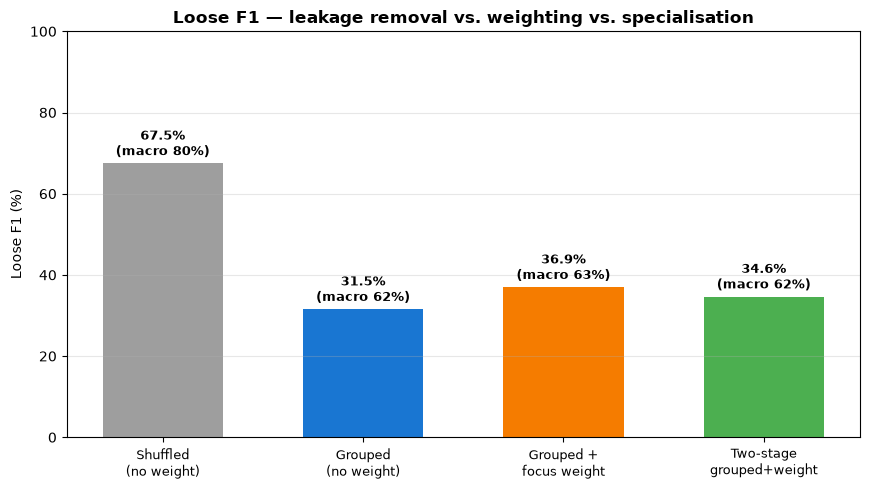


Leakage artifact (shuffled → grouped loose F1): +35.9 pts
If this drop is large, the difficulty was largely a validation artifact.
If grouped loose F1 stays low even after weighting/two-stage, it is genuine —
most cheaply addressed by collecting more independent recordings of that class.


In [8]:
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.utils.class_weight import compute_sample_weight

# Non-grass classes define the 2nd stage (was brick-vs-concrete; now the two hard classes)
NONGRASS = [c for c in classes if c != 'grass']
POS_C  = NONGRASS[0] if NONGRASS else None                 # stage-2 "positive" class
OTH_C  = NONGRASS[1] if len(NONGRASS) > 1 else POS_C       # stage-2 "other" class

def _oof(make_pipe, y, splitter, grp, weight_step=None):
    oof = np.empty(len(y), dtype=object)
    for tr, te in splitter.split(X_tr, y, grp):
        fit_kw = {}
        if weight_step is not None:
            fit_kw[f'{weight_step}__sample_weight'] = compute_sample_weight('balanced', y[tr])
        p = make_pipe(); p.fit(X_tr[tr], y[tr], **fit_kw)
        oof[te] = p.predict(X_tr[te])
    return oof

def _bin_xgb():
    return Pipeline([('sc', StandardScaler()),
        ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
            eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0))])

def two_stage_oof(y_str, splitter, grp):
    """Stage 1: grass vs rest. Stage 2 (on predicted 'rest'): POS_C vs OTH_C."""
    oof = np.empty(len(y_str), dtype=object)
    for tr, te in splitter.split(X_tr, y_str, grp):
        Xtr, Xte, ytr = X_tr[tr], X_tr[te], y_str[tr]
        y1 = (ytr != 'grass').astype(int)                       # 1 = not grass
        m1 = _bin_xgb(); m1.fit(Xtr, y1, xgb__sample_weight=compute_sample_weight('balanced', y1))
        ng = ytr != 'grass'; Xtr2, ytr2 = Xtr[ng], ytr[ng]
        y2 = (ytr2 == POS_C).astype(int)                        # 1 = POS_C
        m2 = None
        if len(np.unique(y2)) == 2:
            m2 = _bin_xgb(); m2.fit(Xtr2, y2, xgb__sample_weight=compute_sample_weight('balanced', y2))
        p1  = m1.predict(Xte)
        pred = np.where(p1 == 0, 'grass', None)
        idx = np.where(p1 == 1)[0]
        if len(idx):
            if m2 is None:
                for j in idx: pred[j] = OTH_C
            else:
                p2 = m2.predict(Xte[idx])
                for k, j in enumerate(idx): pred[j] = POS_C if p2[k] == 1 else OTH_C
        oof[te] = pred
    return oof

make_x   = lambda: Pipeline([('sc', StandardScaler()),
    ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0))])
shuffled = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

experiments = {}
experiments['Shuffled\n(no weight)'] = le.inverse_transform(
    _oof(make_x, y_tr_enc, shuffled, None).astype(int))

if GROUPED:
    grp_cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
    experiments['Grouped\n(no weight)'] = le.inverse_transform(
        _oof(make_x, y_tr_enc, grp_cv, groups).astype(int))
    experiments['Grouped +\nfocus weight'] = le.inverse_transform(
        _oof(make_x, y_tr_enc, grp_cv, groups, weight_step='xgb').astype(int))
    experiments['Two-stage\ngrouped+weight'] = two_stage_oof(y_tr, grp_cv, groups)
else:
    print('[WARN] Not grouped — only the shuffled baseline is shown. Re-run Section 2 for the full comparison.')

# ── Metrics + chart ───────────────────────────────────────────────────
names   = list(experiments)
focus_f = [f1_score(y_tr, p, labels=classes, average=None)[focus_idx]*100 for p in experiments.values()]
macro_f = [f1_score(y_tr, p, labels=classes, average='macro')*100        for p in experiments.values()]
acc_all = [accuracy_score(y_tr, p)*100                                   for p in experiments.values()]

print(f'{"Setup":24s} {FOCUS_CLASS[:8]+" F1":>9s} {"Macro F1":>9s} {"Accuracy":>9s}')
for n, b, m, a in zip(names, focus_f, macro_f, acc_all):
    print(f'{n.replace(chr(10)," "):24s} {b:8.1f}% {m:8.1f}% {a:8.1f}%')

fig_d, ax_d = plt.subplots(figsize=(max(7, 2.2*len(names)), 5))
palette = ['#9E9E9E', '#1976D2', '#F57C00', '#4CAF50'][:len(names)]
bars = ax_d.bar(range(len(names)), focus_f, color=palette, width=0.6)
for bar, b, m in zip(bars, focus_f, macro_f):
    ax_d.text(bar.get_x()+bar.get_width()/2, b+1.0, f'{b:.1f}%\n(macro {m:.0f}%)',
              ha='center', va='bottom', fontweight='bold', fontsize=9)
ax_d.set_xticks(range(len(names))); ax_d.set_xticklabels(names, fontsize=9)
ax_d.set_ylabel(f'{FOCUS_CLASS.capitalize()} F1 (%)'); ax_d.set_ylim(0, max(100, max(focus_f)+12))
ax_d.set_title(f'{FOCUS_CLASS.capitalize()} F1 — leakage removal vs. weighting vs. specialisation',
               fontweight='bold', fontsize=12)
ax_d.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, f'{FOCUS_CLASS}_diagnosis.png'), bbox_inches='tight', dpi=150)
plt.show()

if GROUPED and len(names) >= 2:
    drop = focus_f[0] - focus_f[1]
    print(f'\nLeakage artifact (shuffled → grouped {FOCUS_CLASS} F1): {drop:+.1f} pts')
    print('If this drop is large, the difficulty was largely a validation artifact.')
    print(f'If grouped {FOCUS_CLASS} F1 stays low even after weighting/two-stage, it is genuine —')
    print('most cheaply addressed by collecting more independent recordings of that class.')


## 5. Dashboard — Scores, Confusion Matrices, Feature Importance

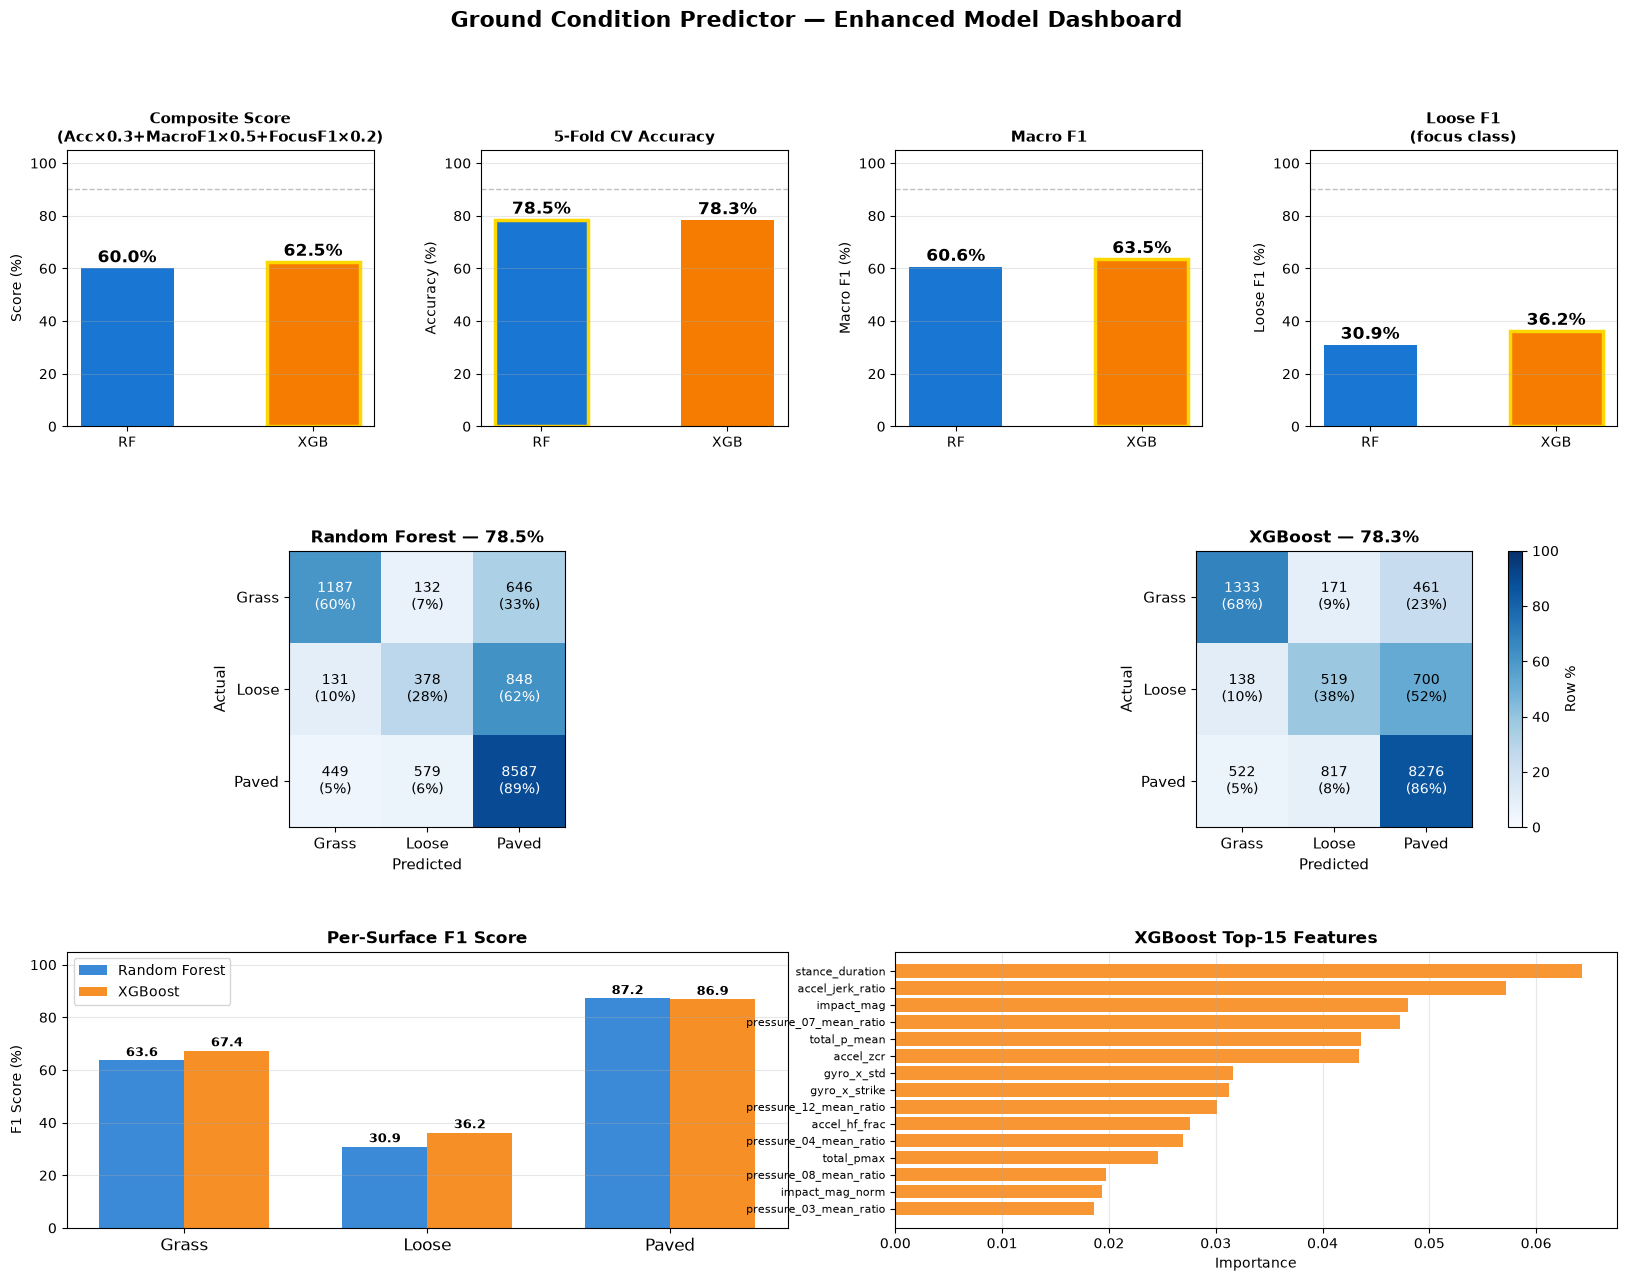


── XGBoost Classification Report ──
              precision    recall  f1-score   support

       grass      0.669     0.678     0.674      1965
       loose      0.344     0.382     0.362      1357
       paved      0.877     0.861     0.869      9615

    accuracy                          0.783     12937
   macro avg      0.630     0.641     0.635     12937
weighted avg      0.789     0.783     0.786     12937



In [9]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Ground Condition Predictor — Enhanced Model Dashboard',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

def score_bar(ax, rf_val, xgb_val, title, ylabel):
    vals  = [rf_val*100, xgb_val*100]
    bars  = ax.bar(['RF','XGB'], vals, color=['#1976D2','#F57C00'], width=0.5)
    for bar,v in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                f'{v:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    ax.set_ylim(0, 105); ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10); ax.grid(axis='y', alpha=0.3)
    ax.axhline(90, color='gray', ls='--', lw=1, alpha=0.5)
    winner_idx = 1 if xgb_val >= rf_val else 0
    bars[winner_idx].set_edgecolor('gold'); bars[winner_idx].set_linewidth(2.5)

# Row 0: four summary bars
score_bar(fig.add_subplot(gs[0,0]), cs_rf,             cs_xgb,             'Composite Score\n(Acc×0.3+MacroF1×0.5+FocusF1×0.2)', 'Score (%)')
score_bar(fig.add_subplot(gs[0,1]), acc_rf,            acc_xgb,            '5-Fold CV Accuracy', 'Accuracy (%)')
score_bar(fig.add_subplot(gs[0,2]), mf1_rf,            mf1_xgb,            'Macro F1', 'Macro F1 (%)')
score_bar(fig.add_subplot(gs[0,3]), f1_rf[focus_idx],  f1_xgb[focus_idx],  f'{FOCUS_CLASS.capitalize()} F1\n(focus class)', f'{FOCUS_CLASS.capitalize()} F1 (%)')

# Row 1: confusion matrices (row-normalised)
for col_pos, y_cv, title, acc in [
    (slice(0,2), y_cv_rf,         f'Random Forest — {acc_rf*100:.1f}%', acc_rf),
    (slice(2,4), y_cv_xgb_labels, f'XGBoost — {acc_xgb*100:.1f}%',     acc_xgb)
]:
    ax = fig.add_subplot(gs[1, col_pos])
    cm = confusion_matrix(y_tr, y_cv, labels=classes)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(len(classes))); ax.set_xticklabels([c.capitalize() for c in classes], fontsize=11)
    ax.set_yticks(range(len(classes))); ax.set_yticklabels([c.capitalize() for c in classes], fontsize=11)
    ax.set_xlabel('Predicted', fontsize=11); ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12)
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(j, i, f'{cm[i,j]}\n({cm_n[i,j]:.0f}%)', ha='center', va='center',
                    color='white' if cm_n[i,j]>55 else 'black', fontsize=10)
plt.colorbar(im, ax=fig.axes[-1], label='Row %')

# Row 2: per-surface F1 grouped bar + XGB feature importance
ax_f1 = fig.add_subplot(gs[2, :2])
x = np.arange(len(classes)); width=0.35
b_rf  = ax_f1.bar(x-width/2, f1_rf*100,  width, label='Random Forest', color='#1976D2', alpha=0.85)
b_xgb = ax_f1.bar(x+width/2, f1_xgb*100, width, label='XGBoost',       color='#F57C00', alpha=0.85)
for bars_ in [b_rf, b_xgb]:
    for bar in bars_:
        ax_f1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                   f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax_f1.set_xticks(x); ax_f1.set_xticklabels([c.capitalize() for c in classes], fontsize=12)
ax_f1.set_ylabel('F1 Score (%)'); ax_f1.set_ylim(0, 105)
ax_f1.set_title('Per-Surface F1 Score', fontweight='bold', fontsize=12)
ax_f1.legend(fontsize=10); ax_f1.grid(axis='y', alpha=0.3)

ax_fi = fig.add_subplot(gs[2, 2:])
xgb_imp = xgb_pipe.named_steps['xgb'].feature_importances_
top_n   = 15; top_idx = np.argsort(xgb_imp)[::-1][:top_n]
ax_fi.barh(range(top_n), xgb_imp[top_idx][::-1], color='#F57C00', alpha=0.8)
ax_fi.set_yticks(range(top_n))
ax_fi.set_yticklabels([FEATURE_COLS[i] for i in top_idx[::-1]], fontsize=8)
ax_fi.set_xlabel('Importance')
ax_fi.set_title('XGBoost Top-15 Features', fontweight='bold', fontsize=12)
ax_fi.grid(axis='x', alpha=0.3)

plt.savefig(os.path.join(CHARTS_DIR, 'dashboard.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\n── XGBoost Classification Report ──')
print(classification_report(y_tr, y_cv_xgb_labels, digits=3))

## 6. Feature Distributions by Surface

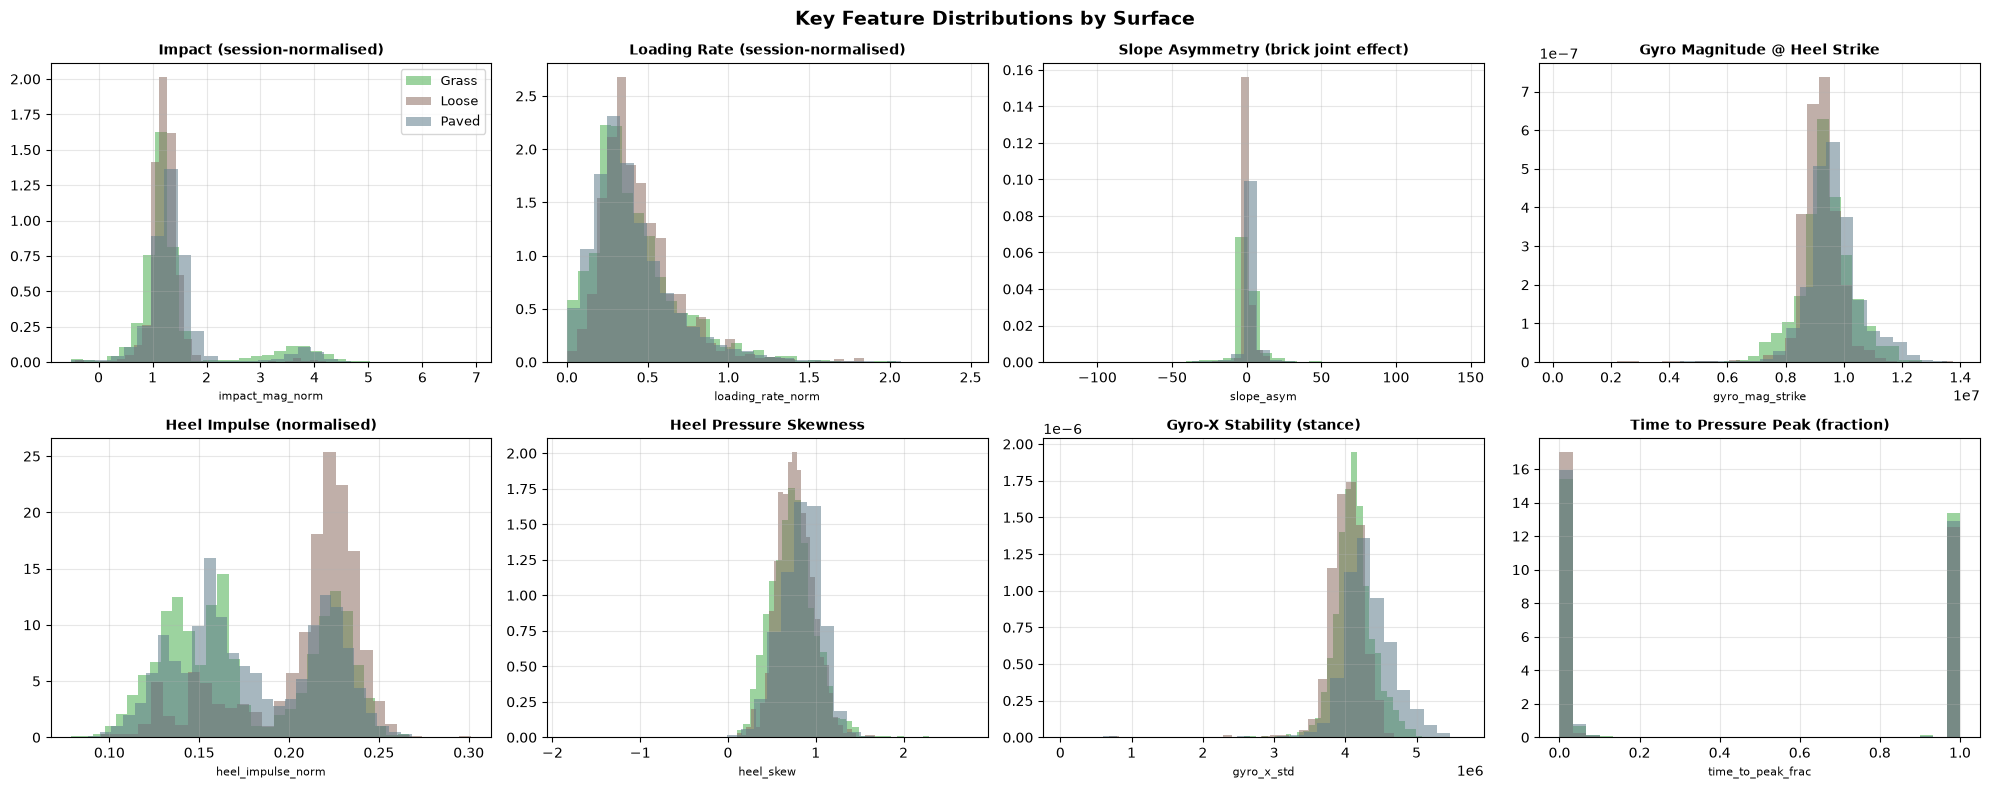

In [10]:
key_feats = ['impact_mag_norm','loading_rate_norm','slope_asym','gyro_mag_strike',
             'heel_impulse_norm','heel_skew','gyro_x_std','time_to_peak_frac']
feat_labels = ['Impact (session-normalised)','Loading Rate (session-normalised)',
               'Slope Asymmetry (brick joint effect)','Gyro Magnitude @ Heel Strike',
               'Heel Impulse (normalised)','Heel Pressure Skewness',
               'Gyro-X Stability (stance)','Time to Pressure Peak (fraction)']

fig2, axes2 = plt.subplots(2, 4, figsize=(20, 8))
fig2.suptitle('Key Feature Distributions by Surface', fontsize=14, fontweight='bold')
for ax, feat, label in zip(axes2.flat, key_feats, feat_labels):
    for surf in ['grass', 'loose', 'paved']:
        vals = train_df[train_df['surface']==surf][feat].dropna()
        ax.hist(vals, bins=30, alpha=0.55, color=SURFACE_COLORS[surf],
                label=surf.capitalize(), density=True)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel(feat, fontsize=8); ax.grid(alpha=0.3)
    if feat == key_feats[0]:
        ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'feature_distributions.png'), bbox_inches='tight', dpi=150)
plt.show()

## 7. Predict on New CSV + Sequence Smoothing

In [ ]:
# Exactly ONE REC_*.csv should sit in the Raw/New Data folder; use it.
_new_files = sorted(glob.glob(os.path.join(RAW_NEW_DIR, REC_GLOB)))
if len(_new_files) != 1:
    raise FileNotFoundError(
        f'Expected exactly 1 {REC_GLOB} in {RAW_NEW_DIR}, found {len(_new_files)}: '
        f'{[os.path.basename(f) for f in _new_files]}'
    )
NEW_CSV_PATH = _new_files[0]
NEW_CSV_NAME = os.path.basename(NEW_CSV_PATH)

print(f'Loading: {NEW_CSV_NAME}  |  Model: {best_name}')
new_raw = pd.read_csv(NEW_CSV_PATH, low_memory=False)
ss_new  = compute_session_stats(new_raw)

pred_frames = []
for sole_id, foot in [(1,'right'), (2,'left')]:
    sub = new_raw[new_raw['sole_id'] == sole_id].copy()
    labelled = label_surface_segments(sub)
    df_proc  = preprocess(labelled if labelled is not None else sub)
    feats = extract_step_features(df_proc, foot_label=foot, session_stats=ss_new)
    if len(feats):
        pred_frames.append(feats)
        print(f'  {foot}: {len(feats)} steps')

pred_df = pd.concat(pred_frames, ignore_index=True)
X_pred  = pred_df[FEATURE_COLS].fillna(0).values

if use_encoded:
    pred_df['predicted_surface'] = le.inverse_transform(best_pipe.predict(X_pred))
    proba = best_pipe.predict_proba(X_pred)
else:
    pred_df['predicted_surface'] = best_pipe.predict(X_pred)
    proba = best_pipe.predict_proba(X_pred)

for i, c in enumerate(classes): pred_df[f'prob_{c}'] = proba[:, i]
pred_df['max_confidence'] = proba.max(axis=1)

# Sequence smoothing
pred_df['smoothed_surface'] = pred_df.groupby('foot')['predicted_surface'].transform(
    lambda s: rolling_majority(s, window=5)
)

print(f'\nRaw predictions:')
print(pred_df.groupby(['foot','predicted_surface']).size().unstack(fill_value=0))
print(f'\nSmoothed predictions:')
print(pred_df.groupby(['foot','smoothed_surface']).size().unstack(fill_value=0))
print(f'\nMean confidence: {pred_df["max_confidence"].mean()*100:.1f}%')

## 7b. File the recording into its owner's folder

In [ ]:
# Move the just-predicted recording out of Raw/New Data and into its owner's
# user folder, so the next Section-2 run folds it into the material training set.

# ── Fill in which user this recording belongs to ──────────────────────
ASSIGN_TO_USER = ''   # ← e.g. 'Amy', 'Catherine', 'Kristian'

if not ASSIGN_TO_USER:
    raise ValueError('Set ASSIGN_TO_USER to the user this recording belongs to before running.')

dest_dir  = os.path.join(USERS_DIR, ASSIGN_TO_USER)
os.makedirs(dest_dir, exist_ok=True)
dest_path = os.path.join(dest_dir, NEW_CSV_NAME)

if os.path.exists(dest_path):
    raise FileExistsError(f'{NEW_CSV_NAME} already exists in {dest_dir}; not overwriting.')

shutil.move(NEW_CSV_PATH, dest_path)
print(f'Moved {NEW_CSV_NAME}  →  {dest_path}')
print('Re-run Section 2 to fold this recording into the material training files.')

## 8. Prediction Visualisation (Raw vs Smoothed)

In [ ]:
surf_to_int = {s: i for i, s in enumerate(classes)}
int_to_surf = {i: s for s, i in surf_to_int.items()}

fig3, axes3 = plt.subplots(2, 2, figsize=(18, 8))
fig3.suptitle(
    f'Prediction vs Smoothed — {NEW_CSV_NAME}\n'
    f'{best_name} | Mean confidence: {pred_df["max_confidence"].mean()*100:.1f}%',
    fontsize=13, fontweight='bold'
)
for ri, foot in enumerate(['right', 'left']):
    sub = pred_df[pred_df['foot'] == foot].reset_index(drop=True)
    x_ax = sub['contact_time_sec'].values
    for ci, (col, title) in enumerate([
        ('predicted_surface', f'{foot.capitalize()} — Raw'),
        ('smoothed_surface',  f'{foot.capitalize()} — Smoothed (window=5)')
    ]):
        ax = axes3[ri, ci]
        vals = sub[col].map(surf_to_int).values
        colors_plot = [SURFACE_COLORS.get(int_to_surf.get(v,'unknown'),'#9E9E9E') for v in vals]
        ax.scatter(x_ax, vals, c=colors_plot, s=25, alpha=0.85, zorder=3)
        if 'surface' in sub.columns:
            gt = sub['surface'].map(surf_to_int)
            ax.step(x_ax, gt.values, where='post', color='black', lw=1.5,
                    alpha=0.5, label='Ground truth')
            ax.legend(fontsize=9)
        ax.set_yticks(list(surf_to_int.values()))
        ax.set_yticklabels([c.capitalize() for c in classes], fontsize=11)
        ax.set_title(title, fontweight='bold', fontsize=11)
        ax.set_xlabel('Contact time (s)'); ax.grid(alpha=0.3)

patches = [plt.Rectangle((0,0),1,1,color=SURFACE_COLORS[s]) for s in classes]
fig3.legend(patches, [c.capitalize() for c in classes], loc='lower center',
            ncol=3, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'sequence_smoothing.png'), bbox_inches='tight', dpi=150)
plt.show()

## 9. Export Predictions

In [ ]:
out_path = os.path.join(PRED_DIR, NEW_CSV_NAME.replace('.csv', '_predictions_v2.csv'))
pred_df[['foot','step_id','contact_time_sec','stance_duration',
         'impact_mag','loading_rate','predicted_surface','smoothed_surface','max_confidence']
       + [f'prob_{c}' for c in classes]
       ].to_csv(out_path, index=False)
print(f'Saved → {out_path}')

## 10. Sequence model — 1D temporal CNN on raw step windows

Instead of hand-engineered per-step summaries, this feeds the model the **raw
multichannel waveform of each step** (9 channels × 64 time-steps) and lets a 1D
CNN learn its own shape/texture detectors — the idea being it can pick up the
brick joint-strike pattern directly.

**Requires PyTorch** (`pip install torch`) and that Sections 1–4 have already run
(it reuses `le`, `classes`, `brick_idx`, `CLASS_WEIGHT_STRENGTH`, and the XGBoost
grouped scores for comparison).

**Read this before trusting the result.** Each step's channels are z-scored
individually, so the CNN sees shape, not magnitude — the same session-invariance
principle as the texture features. Evaluation uses the *same* grouped CV as the
trees, so compare against the **grouped** XGBoost brick F1, never the shuffled one.
With a few thousand steps and brick in a limited number of recordings, a CNN can
easily overfit and lose to the trees; if grouped brick F1 doesn't beat XGBoost,
that's the honest answer, not a tuning failure.

In [11]:
# ── Requires PyTorch:  pip install torch ──────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedGroupKFold

T_LEN = 64
SEQ_CHANNELS = ['heel_sum','fore_sum','total_p','accel_x','accel_y','accel_z',
                'gyro_x','gyro_y','gyro_z']

def _resample_zscore(win, T=T_LEN):
    """[L, C] raw window -> [T, C], each channel z-scored (magnitude removed)."""
    L, C = win.shape
    if L < 2: return None
    xi = np.linspace(0, L-1, T); out = np.empty((T, C), float)
    for c in range(C):
        r = np.interp(xi, np.arange(L), win[:, c]); sd = r.std()
        out[:, c] = (r - r.mean()) / (sd if sd > 1e-8 else 1.0)
    return out

def _channel_matrix(df):
    num = lambda cols: df[cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy(float)
    g   = lambda c: pd.to_numeric(df[c], errors='coerce').fillna(0).to_numpy(float)
    return np.column_stack([
        num(HEEL_SENSORS).sum(1), num(FOREFOOT_SENSORS).sum(1), num(ALL_SENSORS).sum(1),
        g('accel_x'), g('accel_y'), g('accel_z'), g('gyro_x'), g('gyro_y'), g('gyro_z')])

def step_windows_from_df(df):
    peaks = find_step_windows(df)
    if len(peaks) < 2: return [], []
    M = _channel_matrix(df)
    surf_col = df['surface'].values if 'surface' in df.columns else None
    wins, surfs = [], []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        if p2 - p1 < MIN_DP: continue
        w = _resample_zscore(M[p1:p2])
        if w is None: continue
        s = None
        if surf_col is not None:
            seg = pd.Series(surf_col[p1:p2]).dropna()
            if len(seg): s = seg.mode()[0]
        wins.append(w); surfs.append(s)
    return wins, surfs

# Build the raw-window dataset from every user recording
Xseq_l, yseq_l, grp_l = [], [], []
recs = []
if os.path.isdir(USERS_DIR):
    for user in sorted(os.listdir(USERS_DIR)):
        udir = os.path.join(USERS_DIR, user)
        if os.path.isdir(udir):
            recs += sorted(glob.glob(os.path.join(udir, REC_GLOB)))
for path in recs:
    raw = pd.read_csv(path, low_memory=False)
    for sole_id, foot in [(1,'right'), (2,'left')]:
        sub = raw[raw['sole_id'] == sole_id].copy()
        lab = label_surface_segments(sub)
        if lab is None or len(lab) == 0: continue
        lab = preprocess(lab)
        wins, surfs = step_windows_from_df(lab)
        for w, s in zip(wins, surfs):
            if s in list(classes):
                Xseq_l.append(w); yseq_l.append(s); grp_l.append(os.path.basename(path))

Xseq    = np.stack(Xseq_l).astype('float32')     # [N, T, C]
yseq    = le.transform(np.array(yseq_l))
grp_seq = np.array(grp_l)
print('Sequence dataset:', Xseq.shape, '(steps, time, channels)')
print('Class counts:', dict(zip(*np.unique(le.inverse_transform(yseq), return_counts=True))))
_gc = {c: int(np.unique(grp_seq[le.inverse_transform(yseq) == c]).size) for c in classes}
print('Recordings per class:', _gc)
SEQ_SPLITS = int(min(5, min(_gc.values())))
print('Grouped folds:', SEQ_SPLITS)

Sequence dataset: (12937, 64, 9) (steps, time, channels)
Class counts: {'grass': np.int64(1965), 'loose': np.int64(1357), 'paved': np.int64(9615)}
Recordings per class: {'grass': 27, 'loose': 12, 'paved': 59}
Grouped folds: 5


### Train & evaluate under grouped CV

In [12]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(42)

class Conv1dNet(nn.Module):
    def __init__(self, C, n_classes):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv1d(C, 32, 7, padding=3), nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten())
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(64, 64), nn.ReLU(),
                                  nn.Dropout(0.3), nn.Linear(64, n_classes))
    def forward(self, x):                 # x: [B, T, C] -> [B, C, T]
        return self.head(self.body(x.transpose(1, 2)))

def train_fold(Xtr, ytr, Xva, yva, n_classes, cls_w,
               max_epochs=80, patience=12, bs=64, lr=1e-3):
    model = Conv1dNet(Xtr.shape[2], n_classes).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.CrossEntropyLoss(weight=torch.tensor(cls_w, dtype=torch.float32, device=device))
    ds    = TensorDataset(torch.tensor(Xtr), torch.tensor(ytr))
    dl    = DataLoader(ds, batch_size=bs, shuffle=True, drop_last=len(Xtr) >= bs)  # drop_last: avoid size-1 BatchNorm batch
    Xva_t = torch.tensor(Xva).to(device)
    best_f1, best_state, wait = -1.0, None, 0
    for _ in range(max_epochs):
        model.train()
        for xb, yb in dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); lossf(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vp = model(Xva_t).argmax(1).cpu().numpy()
        vf1 = f1_score(yva, vp, average='macro')
        if vf1 > best_f1:
            best_f1, wait = vf1, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience: break
    if best_state: model.load_state_dict(best_state)
    return model

# Softened class weights — reuses the Section-4 CLASS_WEIGHT_STRENGTH dial
_cnt  = np.bincount(yseq, minlength=len(classes)).astype(float)
cls_w = (len(yseq) / (len(classes) * _cnt)) ** CLASS_WEIGHT_STRENGTH
cls_w = cls_w / cls_w.mean()

sgkf_seq = StratifiedGroupKFold(n_splits=SEQ_SPLITS, shuffle=True, random_state=42)
oof = np.full(len(yseq), -1, int)
for fold, (tr, te) in enumerate(sgkf_seq.split(Xseq, yseq, grp_seq), 1):
    # grouped internal validation split (whole recordings) for early stopping
    gtr = np.unique(grp_seq[tr]); rs = np.random.RandomState(fold); rs.shuffle(gtr)
    val_g = set(gtr[:max(1, int(0.2 * len(gtr)))])
    vm = np.array([g in val_g for g in grp_seq[tr]])
    tr_i, va_i = tr[~vm], tr[vm]
    m = train_fold(Xseq[tr_i], yseq[tr_i], Xseq[va_i], yseq[va_i], len(classes), cls_w)
    m.eval()
    with torch.no_grad():
        oof[te] = m(torch.tensor(Xseq[te]).to(device)).argmax(1).cpu().numpy()
    print(f'  fold {fold}/{SEQ_SPLITS} done')

seq_true = le.inverse_transform(yseq)
seq_lbl  = le.inverse_transform(oof)
acc_seq  = accuracy_score(seq_true, seq_lbl)
f1_seq   = f1_score(seq_true, seq_lbl, labels=classes, average=None)
mf1_seq  = float(np.mean(f1_seq))
print(f'\n1D-CNN (grouped) — Acc {acc_seq*100:.1f}%  MacroF1 {mf1_seq*100:.1f}%  BrickF1 {f1_seq[focus_idx]*100:.1f}%')

  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done

1D-CNN (grouped) — Acc 85.3%  MacroF1 71.4%  BrickF1 48.4%


### Compare to the tree baseline (grouped CV)

model                       Brick F1  Macro F1  Accuracy
XGBoost (grouped+weight)       36.2%     63.5%     78.3%
1D-CNN (grouped+weight)        48.4%     71.4%     85.3%


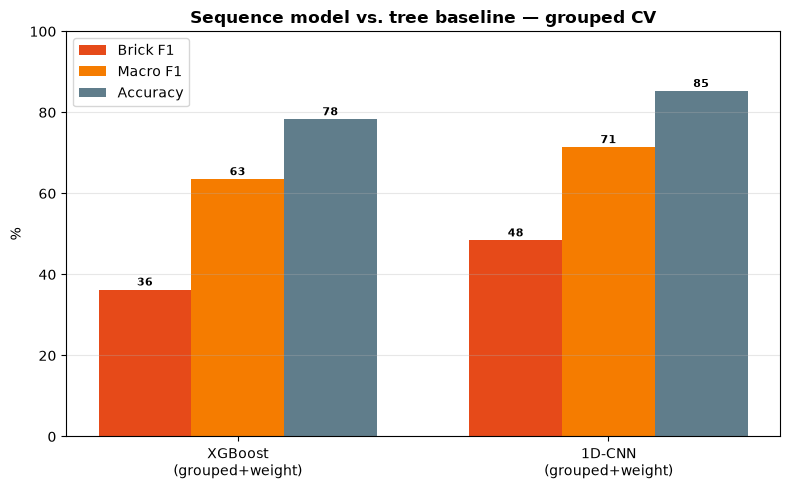


CNN confusion matrix (rows = actual):
       Grass  Loose  Paved
Grass   1401    211    353
Loose    179    606    572
Paved    261    331   9023


In [13]:
labels = ['XGBoost\n(grouped+weight)', '1D-CNN\n(grouped+weight)']
brick  = [f1_xgb[focus_idx]*100, f1_seq[focus_idx]*100]
macro  = [mf1_xgb*100,           mf1_seq*100]
acc    = [acc_xgb*100,           acc_seq*100]

print(f'{"model":26s} {"Brick F1":>9s} {"Macro F1":>9s} {"Accuracy":>9s}')
for n, b, m, a in zip(labels, brick, macro, acc):
    print(f'{n.replace(chr(10)," "):26s} {b:8.1f}% {m:8.1f}% {a:8.1f}%')

fig_s, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2); w = 0.25
ax.bar(x-w, brick, w, label='Brick F1', color='#E64A19')
ax.bar(x,   macro, w, label='Macro F1', color='#F57C00')
ax.bar(x+w, acc,   w, label='Accuracy', color='#607D8B')
for xi, vals in zip(x, zip(brick, macro, acc)):
    for dx, v in zip([-w, 0, w], vals):
        ax.text(xi+dx, v+1, f'{v:.0f}', ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 100)
ax.set_ylabel('%'); ax.grid(axis='y', alpha=0.3); ax.legend()
ax.set_title('Sequence model vs. tree baseline — grouped CV', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'sequence_model_cnn.png'), bbox_inches='tight', dpi=150)
plt.show()

print('\nCNN confusion matrix (rows = actual):')
print(pd.DataFrame(confusion_matrix(seq_true, seq_lbl, labels=classes),
                   index=[c.capitalize() for c in classes],
                   columns=[c.capitalize() for c in classes]).to_string())